In [1]:
import torch
import torch.nn as nn
import json
import os
import pandas as pd
from models.lstm import LSTM as LSTM1
from models.lstm_proj_diff import LSTM as LSTM2
from utils.dataset import TranslateDataset
from torch.utils.data import DataLoader
import tokenizers
import numpy as np
from tqdm import tqdm

In [2]:
df_eval = pd.read_parquet("data/tokenized_eval.parquet")

In [3]:
tokenizer = tokenizers.Tokenizer.from_file("artifacts/tokenizer_10000.json")

In [4]:
dataset_eval = TranslateDataset(
    tokens_src=df_eval['en_tokens'].tolist(),
    tokens_tgt=df_eval['pt_tokens'].tolist(),
    invert_src=True
)

dataloader_eval = DataLoader(dataset_eval, batch_size=64, shuffle=False)

In [5]:
MODELS_TRY = [
    LSTM1, LSTM2
]

In [6]:
PATH_MODELS = "artifacts"

models = {}
for file in os.listdir(PATH_MODELS):
    if file.endswith(".pt"):
        model_name = file[:-3].split("_")[1]
        model_path = os.path.join(PATH_MODELS, file)
        model_config_path = os.path.join("configs", f"{model_name}_config.json")
        
        with open(model_config_path, 'r', encoding='utf-8') as f:
            model_config = json.load(f)
        
        for MODEL_TRY in MODELS_TRY:
            try:
                model = MODEL_TRY(embedding_dim=model_config["embedding_dim"],
                            encoder_bidirectional=model_config["encoder_bidirectional"],
                            encoder_hidden_dim=model_config["encoder_hidden_dim"],
                            encoder_num_layers=model_config["encoder_num_layers"],
                            decoder_hidden_dim=model_config["decoder_hidden_dim"],
                            decoder_num_layers=model_config["decoder_num_layers"],
                            encoder_dropout=model_config["encoder_dropout"],
                            decoder_dropout=model_config["decoder_dropout"],
                            vocab_size=10000, 
                            pad_idx=0)
                model.load_state_dict(torch.load(model_path))
                model.to("cuda" if torch.cuda.is_available() else "cpu")
                model.eval()
                models[model_name] = model
                break
            except RuntimeError:
                continue

In [7]:
print(models.keys())

dict_keys(['v1', 'v11', 'v12', 'v13', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8'])


In [8]:
for model_name, model in models.items():
    print(f"Model: {model_name}")
    total_outputs = []
    for batch in tqdm(dataloader_eval, total=len(dataloader_eval), desc=f"Evaluating {model_name}"):
        enc_tokens, dec_tokens = batch
        enc_tokens = enc_tokens.to('cuda' if torch.cuda.is_available() else 'cpu')
        dec_tokens = dec_tokens.to('cuda' if torch.cuda.is_available() else 'cpu')

        with torch.no_grad():
            outputs = model(enc_tokens, dec_tokens[:, :-1])
        
        outputs = outputs.argmax(dim=-1)

        total_outputs.append(outputs.cpu().numpy())

    total_outputs = np.concatenate(total_outputs, axis=0)

    df_eval[f'{model_name}_pred'] = tokenizer.decode_batch(total_outputs, skip_special_tokens=True)

Model: v1


Evaluating v1:   0%|          | 0/627 [00:00<?, ?it/s]

Evaluating v1: 100%|██████████| 627/627 [00:04<00:00, 154.23it/s]


Model: v11


Evaluating v11: 100%|██████████| 627/627 [00:40<00:00, 15.55it/s]


...

Evaluating v6: 100%|██████████| 627/627 [00:04<00:00, 133.00it/s]


Model: v7


Evaluating v7: 100%|██████████| 627/627 [00:10<00:00, 59.53it/s]


Model: v8


Evaluating v8: 100%|██████████| 627/627 [00:10<00:00, 60.46it/s]


In [9]:
df_eval.head()

,en,pt,en_length,pt_length,en_max_len_word,pt_max_len_word,en_tokens,pt_tokens,v1_pred,v11_pred,v12_pred,v13_pred,v2_pred,v3_pred,v4_pred,v5_pred,v6_pred,v7_pred,v8_pred
0,A workman informs the astronomers that if they...,Um trabalhador informa aos astrônomos que se e...,136,136,11,12,"[5, 36, 923, 473, 2094, 86, 338, 6046, 345, 75...","[5, 1762, 8071, 330, 2278, 1493, 8806, 1646, 3...",E dia or de do que ôn omos que são aliment são...,"Se, ó, de que ôn omos. não jamos têm is. acaso...",Quando m or de do nomes ôn omos. ele encontr. ...,"- plano or de do, ôn omos que os infil tro ire...",E homem or de do seus ôn omos que se torn têm ...,A dia or de que deuses ôn omos que o recus não...,E homem or que que seus ôn omos que o op têm i...,Eu dia or de do que ôn omos que se recus não i...,E dia or de do que ôn omos que o recus não em ...,E dia or de do seus ôn omos que o est não iram...,E homem or de do policiais ôn omos que se est ...
1,Through the gap that the trojans had made to b...,"Através da abertura, que os troianos fizeram p...",155,163,10,13,"[5, 1060, 5813, 338, 74, 643, 385, 338, 597, 7...","[5, 36, 526, 2018, 355, 3079, 2109, 17, 344, 3...",E única vés de minha tura do o o homens ianos ...,"A re re, pa tura, e não do pe.. a. nome. trás....",A porta vess de luz tura do o se tem is já. o ...,S ca vés do sua tura dos os j j ianos j a a a ...,E única vés de morte tura do a o homens ianos ...,"A única vés de noite tura, o é humanos ianos n...",E única vés de minha tura do a o homens ianos ...,Eu única vés de sua tura da a é cientistas v s...,"E única vés do minha tura, o o homens v estão,...","E única vés de sua tura, a é homens v são em o...","E única vés de sua tura da o o homens tos são,..."
2,"In one hour, the tide will reach the depths of...","Dentro de uma hora, a maré vai chegar à cavern...",139,131,7,8,"[5, 1138, 448, 1484, 17, 338, 422, 332, 566, 3...","[5, 39, 327, 597, 332, 408, 1697, 17, 68, 525,...","E u tro de uma semana, quando primeira é, fica...","Se ela os, todos vez, então qual é, ser a mort...","A us us de im noite, não gente é o em a to na....",Bem ela tro de sua vez ela ela quem ra que ter...,"E is tro de uma hora, eu polícia é de para a c...","A out tro de poucos hora, o única é baixa ser ...","E out tro de um hora, um única é que ser ao ci...","Eu u tro de um hora, um polícia é da ser a ter...","E u tro de um hora, o única cha da ser a terra...","E u tro de um hora, o lua é de se a sua na, e ...","E is tro de um hora, o equipe é vai se a super..."
3,"But, if i can believe a recently read scientif...",Recentemente li em uma revista científica que ...,121,116,10,12,"[5, 851, 17, 467, 76, 485, 1479, 68, 6101, 118...","[5, 2918, 2997, 638, 399, 369, 408, 7681, 1759...","E ce mente, dou com história, ífica, o sido ça...",De se pode E files solve solve files enço enço...,E en mente foi da. discussão. ífica. você. çad...,"A per mente foi dou com energia que ífica, tud...","E ce mente, da com das de ífica, foi sido çado...","A ce mente, damos com coisa de ífica, não sido...","E ce mente, da que nova de ífica que o sido ça...","Eu ce mente, dam com cidade chamada ífica, não...","E ce mente, da uma mulher de ífica, a sido çad...","E ce mente, damos com das de ífica, é sido çad...","E ce mente, dou uma briga de ífica, não sido ç..."
4,"Professor croknuff, thinking of having to stud...","O professor croknuff, pensando em estudar um n...",154,157,10,11,"[5, 51, 8386, 462, 330, 3140, 78, 1916, 1352, ...","[5, 50, 2903, 3140, 78, 1916, 1352, 17, 2509, ...","E que de y off,, o que você o pouco tipo ero, ...",""" que está bre en -, que que que... ero. guerr...",E ele de by on o. ele nisso ele. livro. ero. l...,"- tribunal declar ta ale,, declar que bra, hom...","E que de ther le,, o que se o pouco tipo ero, ...","A que de ok, e y o em como o dos tipo ero, vio...",E que de ok ura i y o que que a pouco tipo ero...,"Eu que de t, t, o que como o pouco tipo ero, p...","E que de k t a, que que que a homem grupo ero,...","E 

In [10]:
df_configs = pd.DataFrame([json.load(open(os.path.join("configs", f))) for f in os.listdir("configs") if f.endswith("_config.json")])
df_configs

,invert_src,embedding_dim,encoder_hidden_dim,decoder_hidden_dim,encoder_num_layers,decoder_num_layers,encoder_dropout,decoder_dropout,encoder_bidirectional,batch_size,...,save_steps,eval_steps,device,desc,name,early_stop_patience,early_stop_min_delta,warmup_steps,max_steps,learning_rate
0,False,768,2048,2048,3,3,0.1,0.1,True,64,...,1000,1000,cuda,Corrigindo shapes e projeções,v10,5000,0.0,25000.0,200000.0,0.0001
1,False,768,2048,2048,3,3,0.1,0.1,True,64,...,1000,1000,cuda,Corrigindo shapes e projeções,v11,5000,0.0,25000.0,200000.0,0.0001
2,False,768,2048,2048,3,3,0.1,0.1,True,64,...,1000,1000,cuda,CLippando gradiente e inicializando os params ...,v12,20,0.0,25000.0,400000.0,0.0001
3,False,768,2048,2048,3,3,0.1,0.1,True,64,...,1000,1000,cuda,Pegando somente a última camada do encoder par...,v13,20,0.0,25000.0,400000.0,0.0001
4,True,256,512,512,2,2,0.1,0.1,True,256,...,1000,1000,cuda,Treinamento inicial,v1,5000,0.0,NaN,NaN,NaN
5,True,256,1024,1024,2,2,0.1,0.1,True,256,...,1000,1000,cuda,Aumentando o hidden size do encoder e do decod...,v2,5000,0.0,NaN,NaN,NaN
6,True,256,1024,1024,2,2,0.1,0.3,True,256,...,1000,1000,cuda,Adicionando dropout no decoder para evitar ove...,v3,5000,0.0,NaN,NaN,NaN
7,True,256,512,512,2,2,0.1,0.1,True,1024,...,1000,1000,cuda,Aumentando o batchsize do v1 para treinar mais...,v4,5000,0.0,NaN,NaN,NaN
8,True,256,512,512,2,2,0.1,0.1,True,1024,...,1000,1000,cuda,Adicionando warmup na v4,v5,5000,0.0,5000.0,200000.0,NaN
9,True,256,512,512,3,3,0.3,0.1,True,512,...,1000,1000,cuda,Treinando um modelo mais parrudo,v6,5000,0.0,5000.0,200000.0,0.0001


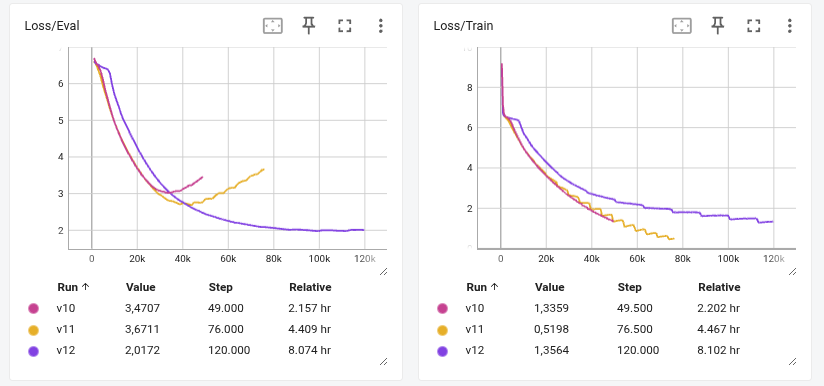

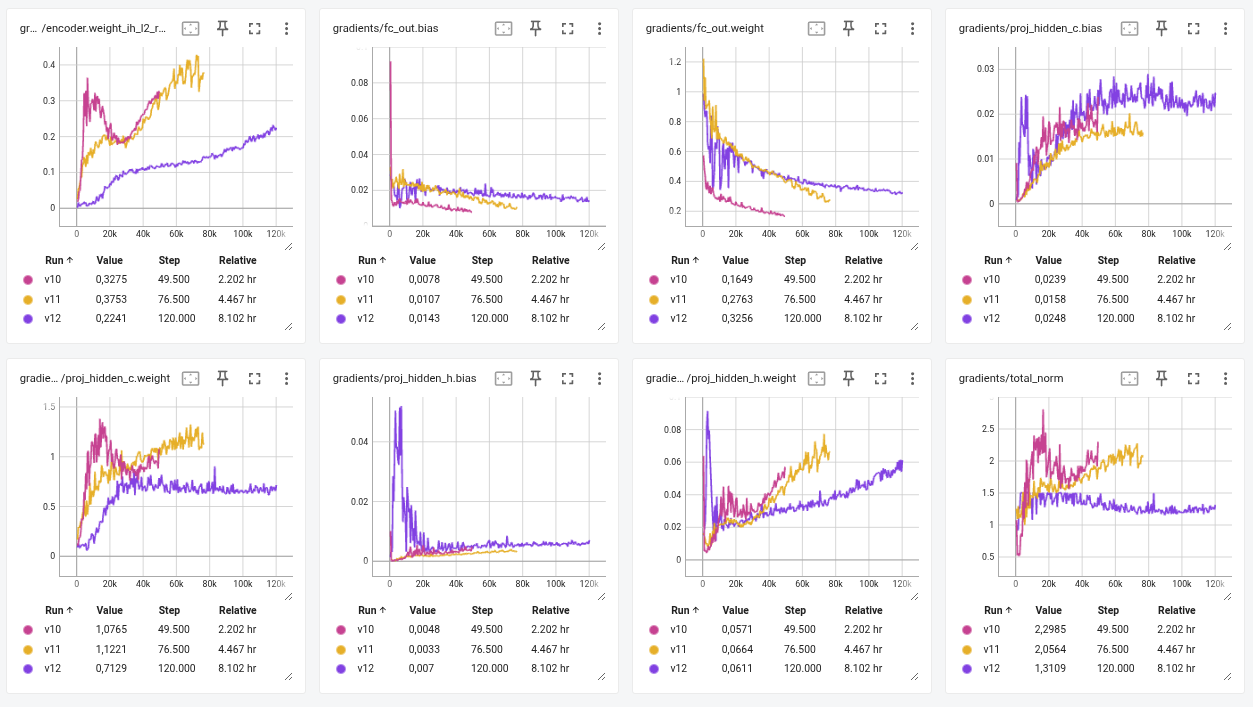

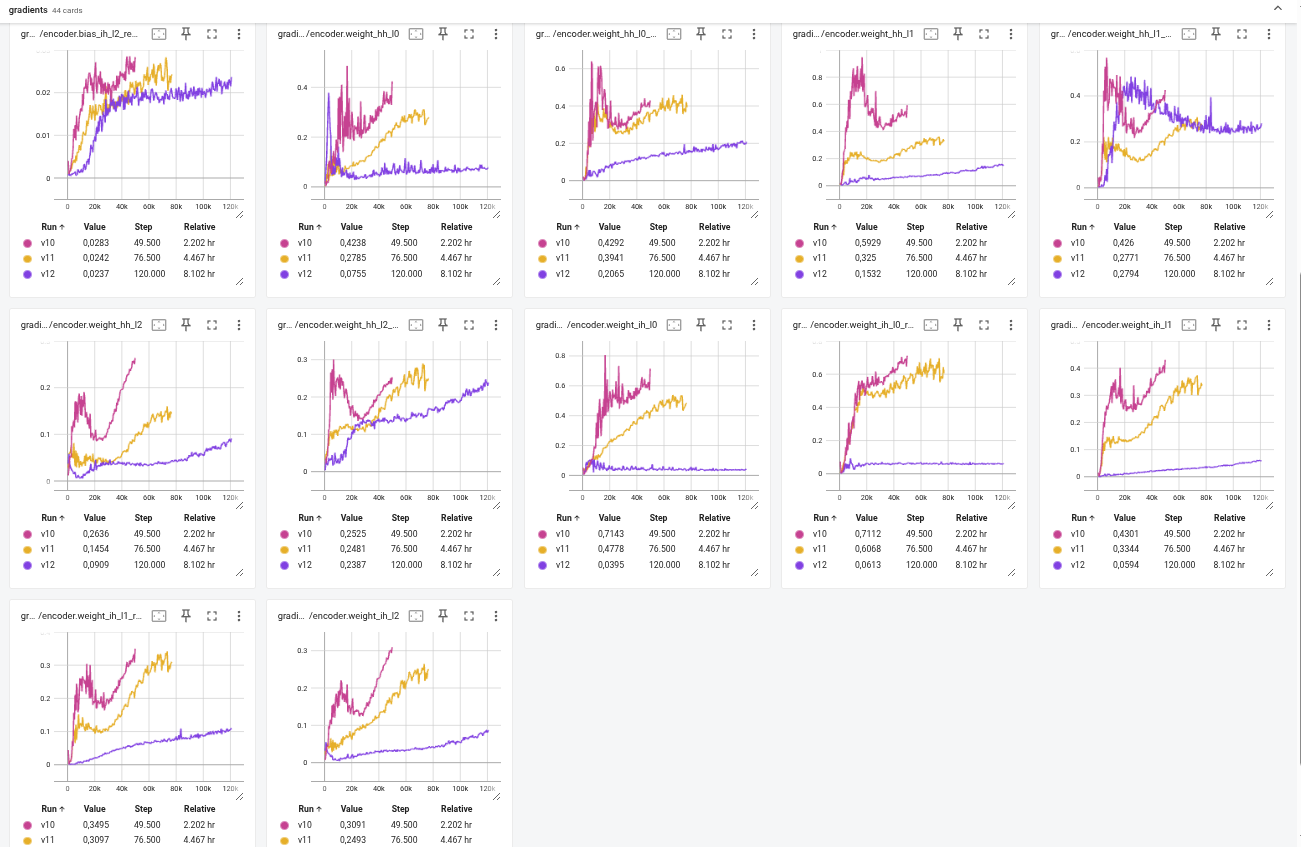

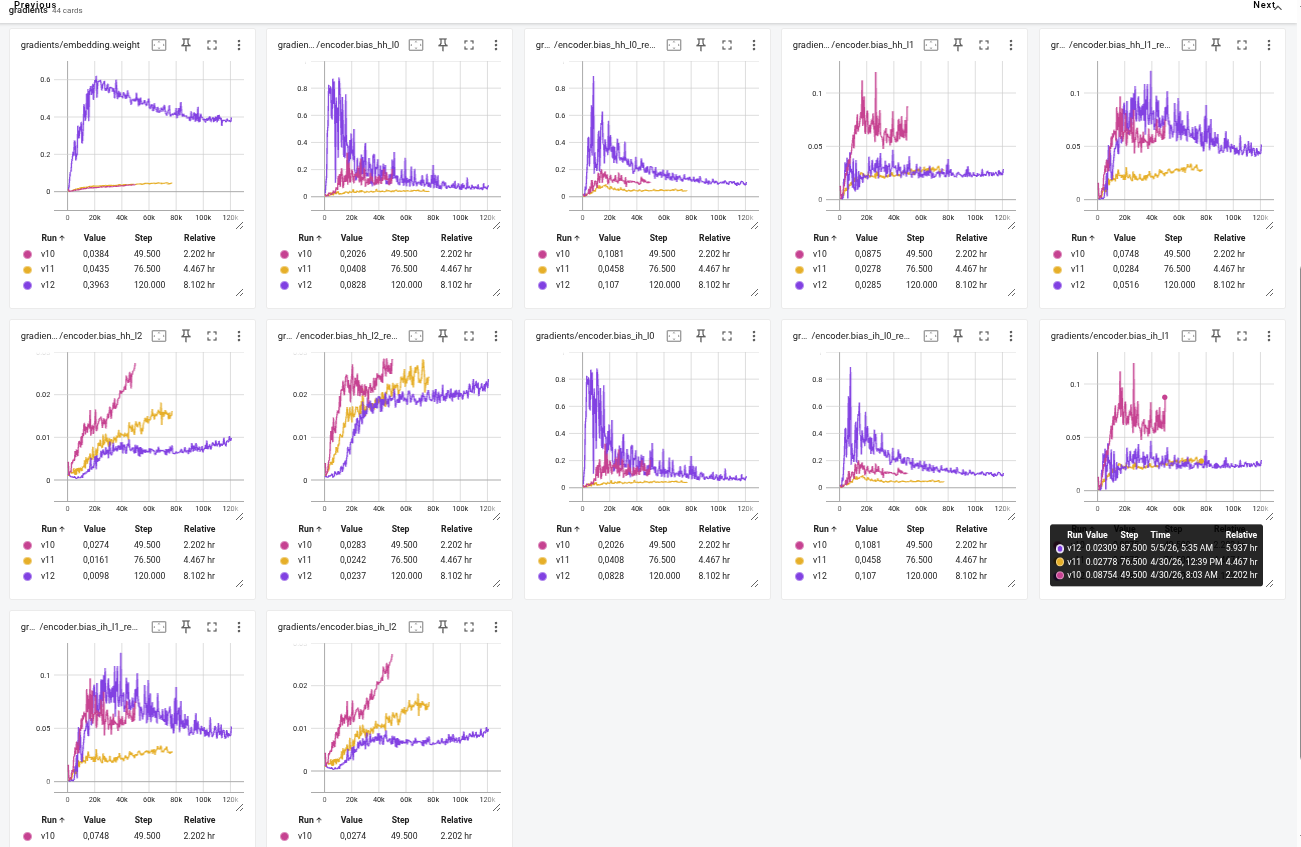

In [20]:
for index in np.random.choice(len(df_eval), size=20, replace=False):
    model_test = 'v12_pred'
    print('Inglês:', df_eval['en'].iloc[index])
    print('Português:', df_eval['pt'].iloc[index])
    print(f'{model_test}:', df_eval[model_test].iloc[index])
    print('-'*200)

Inglês: You moved to the state capital because you wanted to expose fakes and frauds, and fall in love, and write stories in coffee shops.
Português: Mudou para a capital do estado pois queria expor fraudes e falsários, se apaixonar, escrever histórias em cafeterias.
v12_pred: E dando - o cafe em café de escre escrever - sua u des e em s ifica, e ques am por e am de que teria ias, ou ia...........
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: I traveled the route today with a surveyor from one end to the other, and i think prescott might accept my new proposal.
Português: Eu e meu assistente andamos de uma ponta até a outra, hoje... e acho que prescott vai aceitar a minha nova oferta.
v12_pred: E também o al, r em forma forma de mim qual, e, e eu que eu um amos um a a proposta candid marca de arei..............
--------------

In [11]:
for index in np.random.choice(len(df_eval), size=20, replace=False):
    model_test = 'v13_pred'
    print('Inglês:', df_eval['en'].iloc[index])
    print('Português:', df_eval['pt'].iloc[index])
    print(f'{model_test}:', df_eval[model_test].iloc[index])
    print('-'*200)

Inglês: Well, apart from the fact that he's clearly besotted with you, there are certain things he lacks and certain things he has too much of... for me.
Português: Bem, além do fato de que ele está claramente obcecado com você, existem certas coisas que lhe falta e certas coisas que ele tem muito de ... para mim.
v13_pred: Eu, eu de motivo, ele ele tem certo certo ce cado e as, as coisas coisas, você vimos va tem são que ele tem,, errado nós. u!!......
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: So, i'm saying all people need clean air, clean water, arable land, and a good relationship, a language.
Português: Assim, todos precisam de ar limpo, água limpa e terra cultivável e uma boa relação, uma linguagem.".
v13_pred: C, ling os de um quite po, e, pa, lim, in ável, lim lim esperança, e coisa u agem que ente...............
